# S.T.E.A.M. convention planning: 15,000 attendees
**SparkCity • Scenario analysis and decision support**

Established event information: approximately **15,000 attendees** and a **Science, Technology, Engineering, Arts and Mathematics** theme. Attendance is the only established numerical model input. This model treats that as 15,000 unique people, all attending each event day. Change that interpretation if the count actually means total admissions/person-days.

Deliverables: explicit assumptions, simulated demand ranges for traffic/energy/lodging/spending, weather-conditioned comparisons, an air-quality evidence assessment, and a planning dashboard.

These are **conditional planning scenarios**, not causal estimates fitted from previous conventions. Every numerical input except attendance is an illustrative stress-test assumption, not a sourced local estimate. P10–P90 means the central 80% of the chosen simulation draws—not a confidence interval or a real-world probability.

Run with the project `.venv` kernel. Outputs go to a unique local `data/processed/convention/<run>`. S2 is not accessed.
## 1. Evidence and model choices
- Use the completed Day 3 snapshot only as descriptive context. The generated sensor rows do not define a calibrated citywide baseline, actual venue capacities, or convention effects.
- Compare hypothetical venue access patterns and weather conditions. No actual place or date is selected.
- Model weather as an external condition affecting cooling and travel behavior. Do not attribute a temperature or rainfall change to the convention.
- Estimate private-vehicle activity. Fleet-specific emissions require validated factors; ambient concentrations also require dispersion/background data.
- Keep visitor receipts and organizer expenses separate: they belong to different stakeholders and cannot be subtracted to claim city profit.

Methodological sources (not sources for the assumed numbers):
[FHWA planned-event travel characteristics](https://ops.fhwa.dot.gov/publications/fhwaop04010/chapter1.htm) motivates attendance, arrival rates, venue access and capacity checks.
[EPA emissions and dispersion guidance](https://www.epa.gov/moves/how-do-i-model-emissions-intersection) explains why traffic activity alone cannot establish ambient pollutant concentrations.

## Start here: how to read the 27 scenarios

**3 access patterns × 3 weather conditions × 3 durations = 27 combinations.**
These are the complete combinations of this model, not every possible real-world future.
Scenario IDs identify cases; they are not rankings.

1. Run all cells, then open the printed **dashboard.html** link in a browser.
2. Use the planner dashboard selectors to choose access, weather and duration. The linked scenario explorer contains all 27 cases.
3. Compare medians and P10–P90 ranges using the same duration first.
4. Enter only known residual capacities; leave unknowns blank. Read the capacity gaps and operational options before discussing a venue/date.

For example, “5,300 rooms/night (4,100–6,700)” means a median requirement of
5,300 with a central 80% assumption range. It does not mean 5,300 rooms exist.
Total room-nights, electricity and receipts increase with duration; rooms/night
and peak hourly arrivals need not. Repeated lodging/spending values across
venues are expected because those formulas do not depend on venue or weather.

Corrected Day 1–4 processing improves data integrity, not the evidence for our
assumed convention behavior. No real venue/date can yet be recommended.


In [1]:
import json
import hashlib
import base64
from datetime import datetime, timezone
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/sparkcityx").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Start inside SparkCity_Capstone.")
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT = ROOT / "data/processed/convention" / RUN_ID
OUTPUT.mkdir(parents=True, exist_ok=False)
ATTENDEES = 15000
DRAWS = 5000
SEED = 42
sns.set_theme(style="whitegrid")
print("Output:", OUTPUT)

# Optional source context: the simulation itself does not depend on synthetic measurements.
complete = sorted(p.parent for p in (ROOT / "data/processed/day3").glob("*/manifest.json")
                  if json.loads(p.read_text()).get("status") == "complete")
DAY3 = complete[-1] if complete else None
if DAY3:
    coverage = pd.read_csv(DAY3 / "coverage.csv")
    display(coverage)
    coverage.to_csv(OUTPUT / "synthetic_context.csv", index=False)
    print("Synthetic records shown for context only; not used as citywide capacities.")
# Record precisely which corrected pipeline snapshot supplied descriptive context.
context_lineage = {}
if DAY3:
    context_manifest = json.loads((DAY3 / "manifest.json").read_text())
    context_lineage = {
        "day3_run": DAY3.name,
        "day3_manifest_sha256": hashlib.sha256((DAY3 / "manifest.json").read_bytes()).hexdigest(),
        "day2_run": context_manifest.get("day2_run"),
        "day1_run": context_manifest.get("day1_run"),
        "used_to_calibrate_event_assumptions": False,
    }
(OUTPUT / "context_lineage.json").write_text(json.dumps(context_lineage, indent=2))
print("Context lineage:", context_lineage)


Output: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/convention/20260914T212915633517Z


,dataset,rows,start,end,sensors,median_gap_hours,p95_gap_hours
0,traffic,36000,2025-01-01 00:00:00,2025-05-05 23:55:00,3000,250.0,250.0
1,air_quality,36000,2025-01-01 00:00:00,2026-01-10 23:45:00,1800,450.0,450.0
2,weather,36000,2025-01-01 00:00:00,2027-01-20 23:30:00,1200,600.0,600.0
3,energy,36000,2025-01-01 00:00:00,2025-09-07 23:50:00,2400,400.0,400.0
4,occupancy,36000,2025-01-01 00:00:00,2026-01-10 23:45:00,1200,300.0,300.0
5,fiscal,36000,2025-01-01 00:00:00,2026-01-10 23:45:00,1200,300.0,300.0


Synthetic records shown for context only; not used as citywide capacities.
Context lineage: {'day3_run': '20260914T142210469836Z', 'day3_manifest_sha256': '75df465d41eb93b855218bf2856cecb80446c2599e4d21d38b55ad7dca6713bb', 'day2_run': '20260914T135902169587Z', 'day1_run': '20260914T135810735977Z', 'used_to_calibrate_event_assumptions': False}


## 2. Editable assumption register
Triangular distributions describe chosen low/mode/high stress settings. They have **not** been calibrated to visitor surveys. Shared draws are reused for every scenario so comparisons hold the sampled visitor behavior constant.

Venue archetypes describe access choices, not real Spark City sites:
- Transit-focused: short local journeys and high non-car access.
- Mixed-access: intermediate access.
- Car-oriented: longer journeys and more car access.

The weather labels are not assigned to seasons, months or probabilities. Hotel nights are assumed equal to event duration; arrival/departure extensions, travel outside the city, companion visitors, workers and freight are excluded. Road trips count one arrival and departure each event day.

Capacity limits and emissions factors default to unknown. Empty screening results mean **not assessed**, never feasible by default.

In [2]:
# All low/mode/high settings below are illustrative assumptions.
RANGES = {
    "visitor_fraction": (0.40, 0.65, 0.85),
    "people_per_room": (1.3, 1.8, 2.3),
    "people_per_car": (1.3, 1.8, 2.5),
    "peak_arrival_fraction": (0.35, 0.55, 0.75),
    "arrival_window_hours": (1.0, 2.0, 3.0),
    "venue_kwh_per_attendee_day": (3.0, 6.0, 12.0),
    "hotel_incremental_kwh_per_room_night": (8.0, 16.0, 30.0),
    "room_price": (80.0, 150.0, 250.0),
    "nonhotel_visitor_spend_per_day": (40.0, 90.0, 160.0),
    "local_retention_fraction": (0.50, 0.75, 0.90),
    "event_fixed_cost": (100000.0, 250000.0, 500000.0),
    "event_cost_per_attendee_day": (20.0, 35.0, 70.0),
    "access_uncertainty_multiplier": (0.8, 1.0, 1.2),
}
VENUES = {
    "Transit-focused": {"car_share": 0.20, "walk_share": 0.25, "one_way_km": 4.0,
                        "venue_energy_multiplier": 1.0, "fixed_cost_multiplier": 1.2},
    "Mixed-access": {"car_share": 0.45, "walk_share": 0.15, "one_way_km": 8.0,
                     "venue_energy_multiplier": 1.0, "fixed_cost_multiplier": 1.0},
    "Car-oriented": {"car_share": 0.75, "walk_share": 0.05, "one_way_km": 15.0,
                     "venue_energy_multiplier": 1.0, "fixed_cost_multiplier": 0.8},
}
WEATHER = {
    "Comfortable/dry": {"cooling_multiplier": 1.0, "walk_to_car_fraction": 0.0},
    "Hot/dry": {"cooling_multiplier": 1.5, "walk_to_car_fraction": 0.25},
    "Wet": {"cooling_multiplier": 1.1, "walk_to_car_fraction": 0.50},
}
DURATIONS = [2, 3, 4]
# If supplied, these must be residual headroom after ordinary city demand.
HEADROOM = {"rooms_per_night": None, "vehicles_per_hour": None, "energy_kwh_per_day": None,
            "transit_passengers_per_hour": None}
# Optional validated fleet-average factors, grams per vehicle-km.
# Model scope is attendee private cars only; no buses, aircraft, freight or power-generation emissions.
EMISSION_FACTORS_G_PER_KM = {"NOx": None, "PM2.5": None}
# Currency is an assumed common planning dollar unit, not a verified market quote.
assumptions = {"attendees": ATTENDEES, "attendance_interpretation": "unique people attending every event day",
               "ranges_low_mode_high": RANGES, "venue_archetypes": VENUES,
               "weather_conditions": WEATHER, "durations_days": DURATIONS,
               "headroom": HEADROOM, "emission_factors_g_per_km": EMISSION_FACTORS_G_PER_KM,
               "currency": "illustrative planning dollars", "seed": SEED, "draws": DRAWS}
display(pd.DataFrame([{"parameter": k, "low": v[0], "mode": v[1], "high": v[2],
                      "evidence": "illustrative; needs local calibration"} for k, v in RANGES.items()]))

,parameter,low,mode,high,evidence
0,visitor_fraction,0.40,0.65,0.85,illustrative; needs local calibration
1,people_per_room,1.30,1.80,2.30,illustrative; needs local calibration
2,people_per_car,1.30,1.80,2.50,illustrative; needs local calibration
3,peak_arrival_fraction,0.35,0.55,0.75,illustrative; needs local calibration
4,arrival_window_hours,1.00,2.00,3.00,illustrative; needs local calibration
5,venue_kwh_per_attendee_day,3.00,6.00,12.00,illustrative; needs local calibration
6,hotel_incremental_kwh_per_room_night,8.00,16.00,30.00,illustrative; needs local calibration
7,room_price,80.00,150.00,250.00,illustrative; needs local calibration
8,nonhotel_visitor_spend_per_day,40.00,90.00,160.00,illustrative; needs local calibration
9,local_retention_fraction,0.50,0.75,0.90,illustrative; needs local calibration


## 3. Transparent calculation model
For each sampled assumption set:
- Visitors = attendance × visitor fraction; person-days = attendance × duration.
- Rooms/night = ceiling(visitors ÷ people/room); room-nights = rooms × duration.
- Daily arriving cars = ceiling(attendance × car share ÷ people/car); local vehicle-km = twice arrivals × distance × duration.
- Peak event arrivals/hour = daily arriving cars × peak share ÷ arrival-window hours. This is added demand, not a congestion-delay prediction.
- Event electricity = venue person-days × venue intensity + occupied room-nights × incremental hotel intensity, adjusted by the assumed weather multiplier.
- Potential gross visitor receipts = hotel room-nights × price + visitor-days × nonhotel spending. Retained gross spending applies a retention assumption; it is not profit, GDP, tax revenue or a multiplier effect.
- Organizer cost = assumed fixed cost + per-attendee-day cost. Ticket/sponsor income is unknown, so organizer profit is not estimated.

The no-convention event contribution is zero by construction. This estimates added event demand, not total city conditions. Displacement of ordinary visitors, local resident spending substitution, congestion feedback, supply shortages and price responses are not modeled. Financial potential assumes demand can be served; capacity checks may contradict that.
- Peak transit passenger arrivals/hour = attendance × transit share × peak fraction ÷ arrival-window hours. This requires separate service-capacity evidence; reduced car demand does not imply sufficient transit.


In [3]:
def draw_inputs(n, seed):
    if n <= 0:
        raise ValueError("n must be positive")
    rng = np.random.default_rng(seed)
    return pd.DataFrame({k: rng.triangular(*limits, size=n) for k, limits in RANGES.items()})

def simulate(inputs, attendees, duration, venue, weather, emission_factors=None):
    if not np.isfinite([attendees, duration]).all() or attendees < 0 or duration <= 0:
        raise ValueError("Attendance must be nonnegative and duration positive")
    x = inputs
    if not np.isfinite(x.to_numpy()).all():
        raise ValueError("Inputs must be finite")
    positive = ["people_per_room", "people_per_car", "arrival_window_hours",
                "access_uncertainty_multiplier"]
    if (x[positive] <= 0).any().any():
        raise ValueError("Sharing ratios, arrival window and access multiplier must be positive")
    for name in ("visitor_fraction", "peak_arrival_fraction", "local_retention_fraction"):
        if not x[name].between(0, 1).all():
            raise ValueError(f"{name} must be a fraction")
    if (x < 0).any().any():
        raise ValueError("Negative inputs are not supported")
    if not 0 <= venue["car_share"] <= 1 or not 0 <= venue["walk_share"] <= 1 - venue["car_share"]:
        raise ValueError("Invalid mode shares")
    if not 0 <= weather["walk_to_car_fraction"] <= 1 or weather["cooling_multiplier"] <= 0:
        raise ValueError("Invalid weather assumptions")
    for name in ("one_way_km", "venue_energy_multiplier", "fixed_cost_multiplier"):
        if not np.isfinite(venue[name]) or venue[name] < 0:
            raise ValueError(f"Invalid venue assumption: {name}")
    if not np.isfinite(weather["cooling_multiplier"]):
        raise ValueError("Weather multiplier must be finite")
    visitors = attendees * x["visitor_fraction"]
    rooms = np.ceil(visitors / x["people_per_room"])
    walk = venue["walk_share"] * (1 - weather["walk_to_car_fraction"])
    car = np.clip(venue["car_share"] * x["access_uncertainty_multiplier"] +
                  venue["walk_share"] * weather["walk_to_car_fraction"], 0, 1 - walk)
    transit = 1 - car - walk
    arrivals = np.ceil(attendees * car / x["people_per_car"])
    vkm = 2 * arrivals * venue["one_way_km"] * duration
    peak = arrivals * x["peak_arrival_fraction"] / x["arrival_window_hours"]
    venue_energy = attendees * duration * x["venue_kwh_per_attendee_day"] * venue["venue_energy_multiplier"]
    hotel_energy = rooms * duration * x["hotel_incremental_kwh_per_room_night"]
    energy = (venue_energy + hotel_energy) * weather["cooling_multiplier"]
    gross = rooms * duration * x["room_price"] + visitors * duration * x["nonhotel_visitor_spend_per_day"]
    result = pd.DataFrame({
        "draw": x.index, "attendee_days": attendees * duration,
        "visitors": visitors, "car_share": car, "walk_share": walk, "transit_share": transit,
        "arriving_cars_per_day": arrivals, "private_vehicle_trips_total": 2 * arrivals * duration,
        "private_vehicle_km": vkm, "peak_arriving_vehicles_per_hour": peak,
        "transit_passenger_arrivals_per_day": attendees * transit,
        "peak_transit_passengers_per_hour": attendees * transit * x["peak_arrival_fraction"] / x["arrival_window_hours"],
        "rooms_per_night": rooms, "room_nights": rooms * duration,
        "incremental_energy_kwh": energy, "incremental_energy_kwh_per_day": energy / duration,
        "potential_gross_visitor_receipts": gross,
        "potential_retained_gross_spending": gross * x["local_retention_fraction"],
        "organizer_cost": x["event_fixed_cost"] * venue["fixed_cost_multiplier"] +
                          attendees * duration * x["event_cost_per_attendee_day"],
    })
    for pollutant, factor in (EMISSION_FACTORS_G_PER_KM if emission_factors is None else emission_factors).items():
        if factor is not None and (not np.isfinite(factor) or factor < 0):
            raise ValueError("Emissions factors must be finite and nonnegative")
        result[pollutant + "_private_vehicle_kg"] = vkm * factor / 1000 if factor is not None else np.nan
    return result

draws = draw_inputs(DRAWS, SEED)
results = []
for venue_name, weather_name, duration in product(VENUES, WEATHER, DURATIONS):
    result = simulate(draws, ATTENDEES, duration, VENUES[venue_name], WEATHER[weather_name])
    result["venue"], result["weather"], result["duration_days"] = venue_name, weather_name, duration
    results.append(result)
samples = pd.concat(results, ignore_index=True)
print(len(results), "scenarios;", len(samples), "draws total")
scenario_keys = ["venue", "weather", "duration_days"]
catalog = pd.DataFrame([
    {"scenario_id": f"S{i:02d}", "venue": venue, "weather": weather, "duration_days": duration}
    for i, (venue, weather, duration) in enumerate(product(VENUES, WEATHER, DURATIONS), 1)
])
samples = samples.merge(catalog, on=scenario_keys, validate="many_to_one")
catalog.to_csv(OUTPUT / "scenario_catalog.csv", index=False)


27 scenarios; 135000 draws total


## 4. Verification and conservation checks
Check repeatability, travel-mode accounting, person-days, monotonic duration effects and unchanged exogenous weather assumptions. A zero-attendance test must have zero visitor demand; fixed organizer costs can remain because staging costs are a separate decision.

In [4]:
assert draws.equals(draw_inputs(DRAWS, SEED))
assert np.allclose(samples["car_share"] + samples["walk_share"] + samples["transit_share"], 1)
assert samples["attendee_days"].eq(ATTENDEES * samples["duration_days"]).all()
assert samples["room_nights"].eq(samples["rooms_per_night"] * samples["duration_days"]).all()
assert (samples["private_vehicle_km"] >= 0).all()
v, w = VENUES["Transit-focused"], WEATHER["Comfortable/dry"]
zero = simulate(draws.iloc[:10], 0, 3, v, w)
for col in ["visitors", "rooms_per_night", "private_vehicle_km",
            "incremental_energy_kwh", "potential_gross_visitor_receipts"]:
    assert zero[col].eq(0).all(), col
two = simulate(draws, ATTENDEES, 2, v, w)
four = simulate(draws, ATTENDEES, 4, v, w)
assert np.allclose(four["private_vehicle_km"], 2 * two["private_vehicle_km"])
assert np.allclose(four["incremental_energy_kwh"], 2 * two["incremental_energy_kwh"])
hot = simulate(draws, ATTENDEES, 2, v, WEATHER["Hot/dry"])
assert (hot["incremental_energy_kwh"] > two["incremental_energy_kwh"]).all()
assert (hot["private_vehicle_km"] >= two["private_vehicle_km"]).all()
assert samples["NOx_private_vehicle_kg"].isna().all() if EMISSION_FACTORS_G_PER_KM["NOx"] is None else True
bad = draws.iloc[:1].copy()
bad["people_per_car"] = 0
try:
    simulate(bad, ATTENDEES, 3, v, w)
except ValueError:
    pass
else:
    raise AssertionError("Zero divisor was accepted")
# Check factor units without assigning an invented default factor.
assert 1000 * 2 / 1000 == 2  # 1000 vehicle-km × 2 g/km = 2 kg.
print("Reproducibility, conservation, boundary and direction checks passed.")
assert len(catalog) == 27 and not catalog.duplicated(scenario_keys).any()
assert samples.groupby("scenario_id").size().eq(DRAWS).all()
assert samples.groupby(["duration_days", "draw"])["rooms_per_night"].nunique().eq(1).all()
assert samples.groupby(["duration_days", "draw"])["potential_gross_visitor_receipts"].nunique().eq(1).all()
factor_test = simulate(draws.iloc[:10], ATTENDEES, 3, v, w, {"test": 2.0})
assert np.allclose(factor_test["test_private_vehicle_kg"], factor_test["private_vehicle_km"] * 2 / 1000)
assert zero["peak_transit_passengers_per_hour"].eq(0).all()
print("All 27 combinations, equal-demand invariants and emissions conversion verified.")


Reproducibility, conservation, boundary and direction checks passed.
All 27 combinations, equal-demand invariants and emissions conversion verified.


## 5. Simulation ranges and capacity screening
Quantiles summarize the selected assumption distributions. Do not call the fraction of draws exceeding a threshold a calibrated risk probability. The scenario-screening pass requires all four supplied residual capacities (hotel rooms, road arrivals, transit passengers and daily electricity); missing inputs leave overall feasibility unassessed.

Peak vehicle arrivals do not predict intersection delay. Rooms must be available in the relevant hotel catchment. Energy capacity here is daily kWh headroom: electrical peak kW and grid constraints need a separate load profile.

In [5]:
METRICS = ["arriving_cars_per_day", "peak_transit_passengers_per_hour", "private_vehicle_km", "peak_arriving_vehicles_per_hour", "rooms_per_night",
           "room_nights", "incremental_energy_kwh", "incremental_energy_kwh_per_day",
           "potential_gross_visitor_receipts", "potential_retained_gross_spending", "organizer_cost"]
summary = (samples.groupby(["venue", "weather", "duration_days"])[METRICS]
           .quantile([.1, .5, .9]).rename_axis(index=["venue", "weather", "duration_days", "quantile"])
           .reset_index())
screen_rows = []
headroom_metrics = {"rooms_per_night": "rooms_per_night",
                    "vehicles_per_hour": "peak_arriving_vehicles_per_hour",
                    "energy_kwh_per_day": "incremental_energy_kwh_per_day",
                    "transit_passengers_per_hour": "peak_transit_passengers_per_hour"}
for key, group in samples.groupby(["venue", "weather", "duration_days"]):
    row = dict(zip(["venue", "weather", "duration_days"], key))
    passes = []
    for constraint, metric in headroom_metrics.items():
        capacity = HEADROOM[constraint]
        if capacity is None:
            row[constraint + "_exceedance_fraction"] = np.nan
        else:
            if not np.isfinite(capacity) or capacity < 0:
                raise ValueError("Residual capacities must be finite and nonnegative")
            row[constraint + "_exceedance_fraction"] = float((group[metric] > capacity).mean())
            passes.append(group[metric] <= capacity)
    row["all_constraints_assessed"] = len(passes) == len(headroom_metrics)
    row["joint_pass_fraction"] = float(np.logical_and.reduce(passes).mean()) if row["all_constraints_assessed"] else np.nan
    screen_rows.append(row)
screening = pd.DataFrame(screen_rows)
summary = summary.merge(catalog, on=scenario_keys, validate="many_to_one")
screening = screening.merge(catalog, on=scenario_keys, validate="one_to_one")
print("Computed ranges for all 27 cases. Read the formatted dashboard below.")
summary.to_csv(OUTPUT / "scenario_quantiles.csv", index=False)
screening.to_csv(OUTPUT / "capacity_screening.csv", index=False)
samples.to_parquet(OUTPUT / "simulation_draws.parquet", index=False)

Computed ranges for all 27 cases. Read the formatted dashboard below.


## 6. Paired comparisons and assumption sensitivity
Use identical visitor draws to compare a three-day event under different access/weather assumptions. Room demand is independent of venue archetype here; the model cannot claim one area has more hotel availability.

Spearman rank association between sampled inputs and outcomes identifies influential assumptions within this design. It is not a causal effect or a fitted impact from city observations. Weather and venue scenarios have no assigned occurrence probabilities. Do not average them into an expected forecast.

In [6]:
reference = samples[(samples["venue"] == "Transit-focused") &
                    (samples["weather"] == "Comfortable/dry") & (samples["duration_days"] == 3)].set_index("draw")
compare_rows = []
for venue_name, weather_name in product(VENUES, WEATHER):
    alternative = samples[(samples["venue"] == venue_name) & (samples["weather"] == weather_name) &
                          (samples["duration_days"] == 3)].set_index("draw")
    for metric in ["private_vehicle_km", "incremental_energy_kwh", "organizer_cost"]:
        delta = 100 * (alternative[metric] / reference[metric] - 1)
        compare_rows.append({"venue": venue_name, "weather": weather_name, "metric": metric,
                             "change_p10_pct": delta.quantile(.1), "change_median_pct": delta.median(),
                             "change_p90_pct": delta.quantile(.9)})
comparisons = pd.DataFrame(compare_rows)
comparisons.to_csv(OUTPUT / "paired_comparisons.csv", index=False)
sensitivity_rows = []
for target in ["private_vehicle_km", "rooms_per_night", "incremental_energy_kwh",
               "potential_gross_visitor_receipts", "organizer_cost"]:
    for parameter in draws.columns:
        # Pearson correlation of ranks implements Spearman without another dependency.
        rho = draws[parameter].rank().corr(reference[target].rank())
        sensitivity_rows.append({"output": target, "assumption": parameter, "rank_correlation": rho})
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(OUTPUT / "assumption_sensitivity.csv", index=False)
display(sensitivity.sort_values("rank_correlation", key=lambda x: x.abs(), ascending=False).head(12))

,output,assumption,rank_correlation
63,organizer_cost,event_cost_per_attendee_day,0.978229
2,private_vehicle_km,people_per_car,-0.845272
13,rooms_per_night,visitor_fraction,0.774709
31,incremental_energy_kwh,venue_kwh_per_attendee_day,0.680086
39,potential_gross_visitor_receipts,visitor_fraction,0.614437
32,incremental_energy_kwh,hotel_incremental_kwh_per_room_night,0.589160
14,rooms_per_night,people_per_room,-0.586499
47,potential_gross_visitor_receipts,nonhotel_visitor_spend_per_day,0.567211
12,private_vehicle_km,access_uncertainty_multiplier,0.510574
46,potential_gross_visitor_receipts,room_price,0.433340


## 7. Readable dashboard: all 27 cases

Open each duration section to compare nine scenarios, with the same units and
plain-language labels. Dots show medians; whiskers show P10–P90 assumption ranges.
The detailed table includes every case, lodging, travel, energy and separate financial measures.

A transit-focused case reduces car demand **by assumption**, while requiring
more transit passengers to be served. Comfortable weather reduces modeled
cooling **by assumption**. Neither establishes the best actual site or date.

Unknown capacity is labeled **Not fully assessed**, never “safe.”
Air-quality concentrations remain **Not estimated**. Weather labels are conditions
to plan for, not convention-caused changes or calendar forecasts.


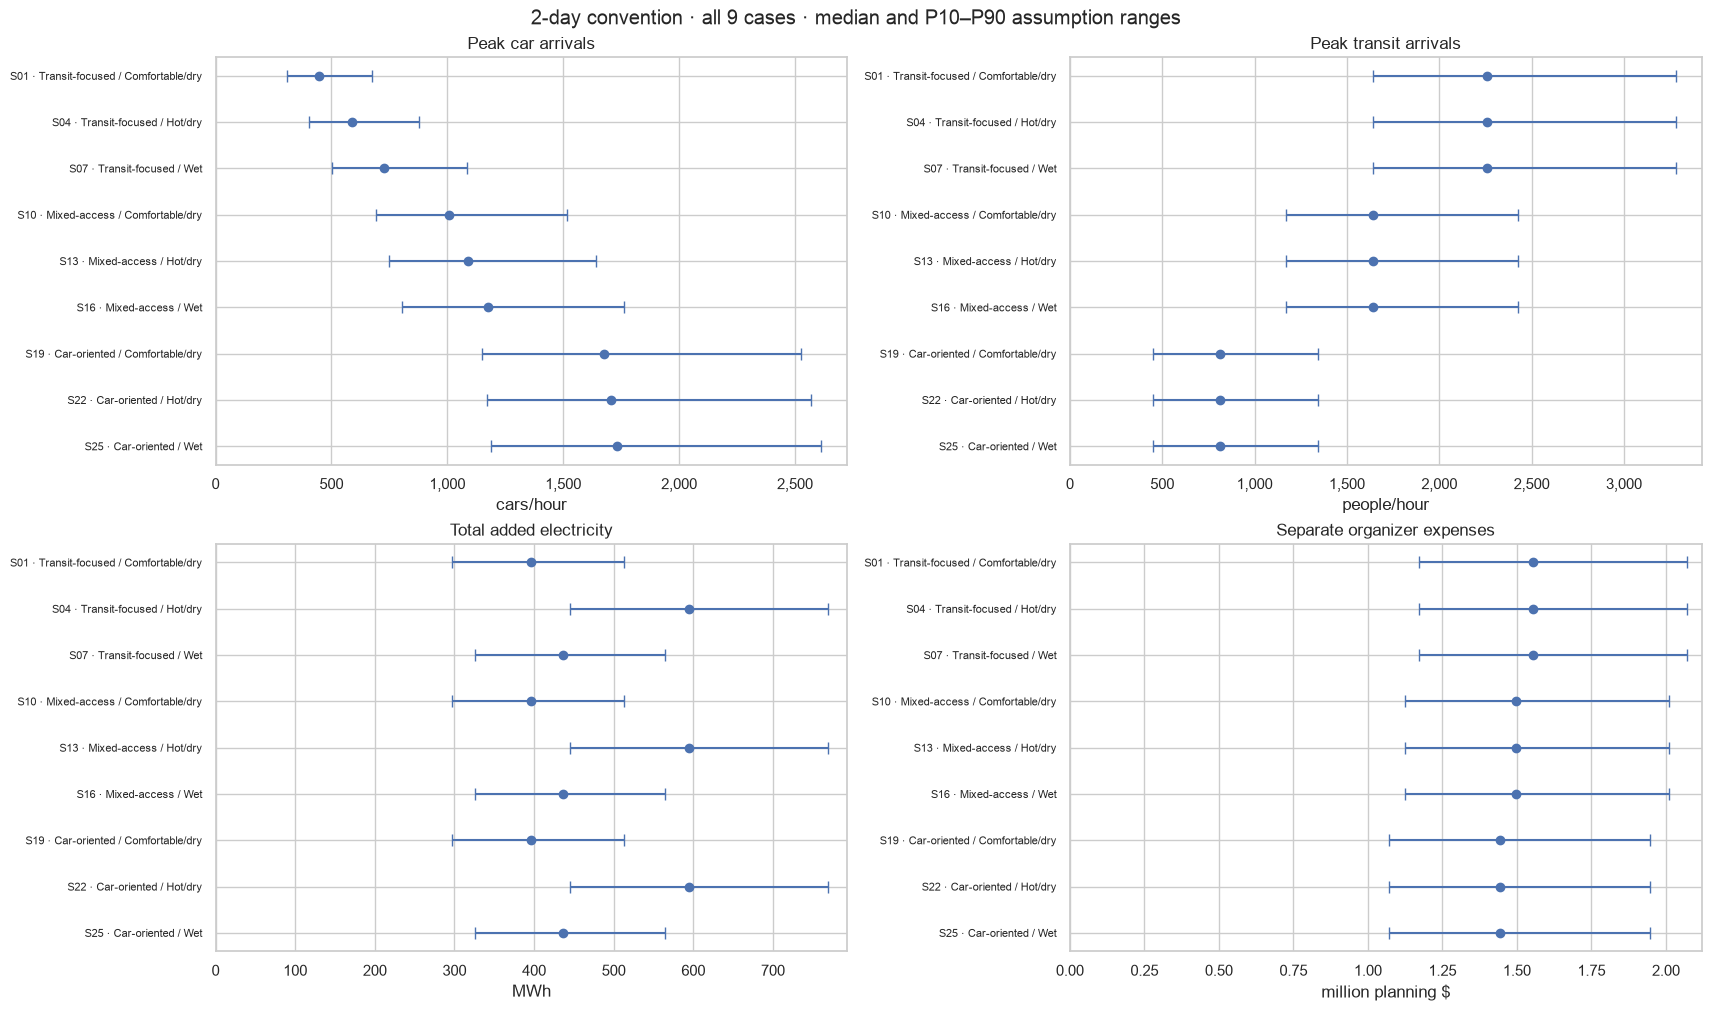

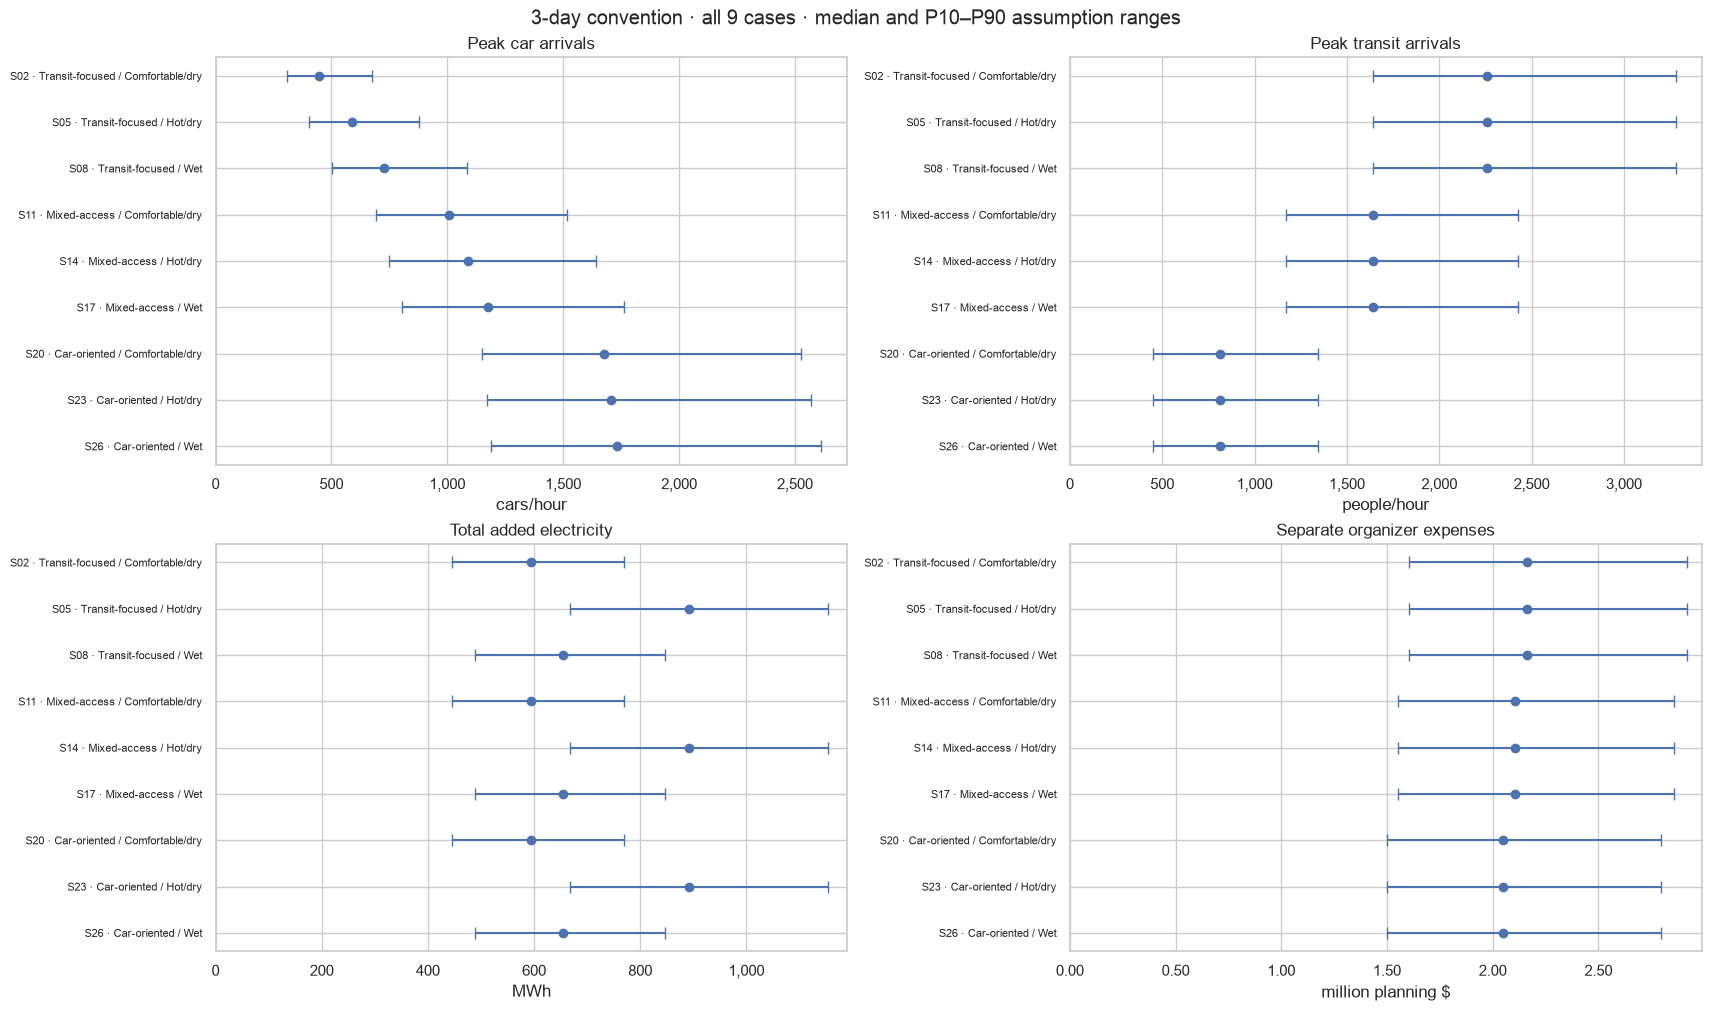

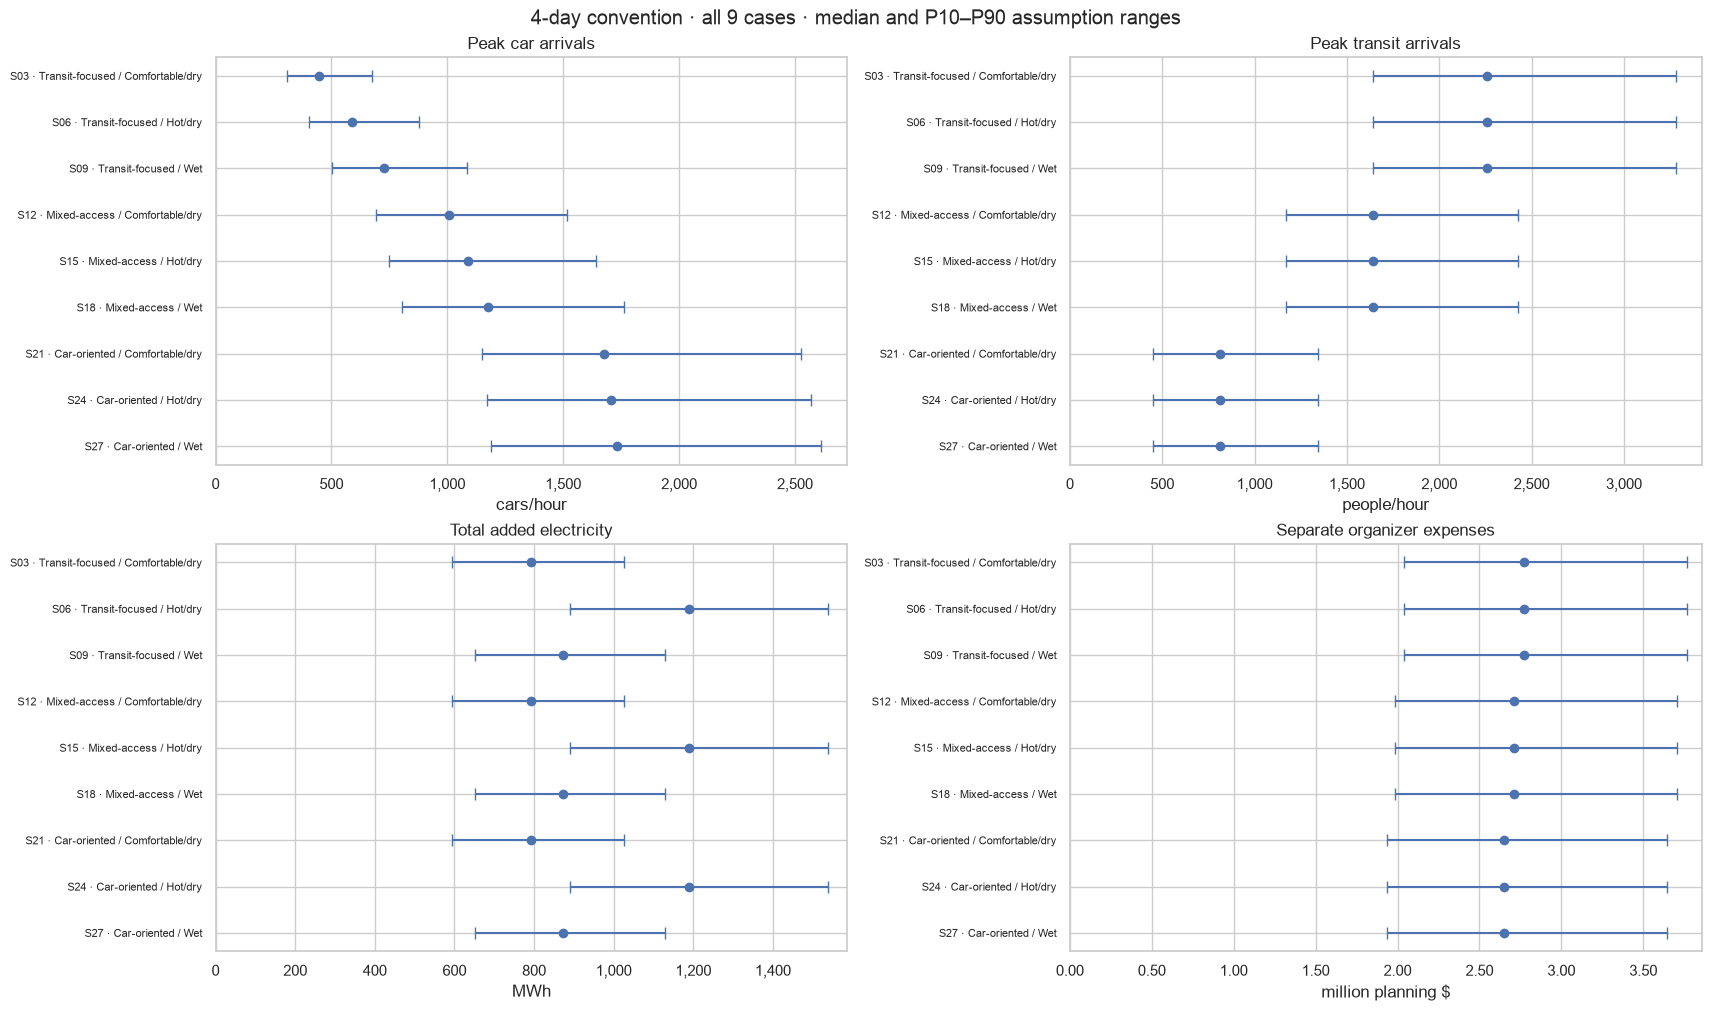

,Scenario,Access,Weather condition,Days,Capacity screening
0,S01,Transit-focused,Comfortable/dry,2,Not fully assessed — residual capacity missing
1,S02,Transit-focused,Comfortable/dry,3,Not fully assessed — residual capacity missing
2,S03,Transit-focused,Comfortable/dry,4,Not fully assessed — residual capacity missing
3,S04,Transit-focused,Hot/dry,2,Not fully assessed — residual capacity missing
4,S05,Transit-focused,Hot/dry,3,Not fully assessed — residual capacity missing
5,S06,Transit-focused,Hot/dry,4,Not fully assessed — residual capacity missing
6,S07,Transit-focused,Wet,2,Not fully assessed — residual capacity missing
7,S08,Transit-focused,Wet,3,Not fully assessed — residual capacity missing
8,S09,Transit-focused,Wet,4,Not fully assessed — residual capacity missing
9,S10,Mixed-access,Comfortable/dry,2,Not fully assessed — residual capacity missing


Open this file in your browser:


/Users/hakeem/Projects/SparkCity_Capstone/data/processed/convention/20260914T212915633517Z/dashboard.html

/Users/hakeem/Projects/SparkCity_Capstone/data/processed/convention/20260914T212915633517Z/dashboard.html


In [7]:
from html import escape
from matplotlib.ticker import StrMethodFormatter
from IPython.display import FileLink

# Unit conversions are presentation-only; exported numerical results retain original units.
DISPLAY_METRICS = [
    ("peak_arriving_vehicles_per_hour", "Peak car arrivals", "cars/hour", 1),
    ("peak_transit_passengers_per_hour", "Peak transit arrivals", "people/hour", 1),
    ("rooms_per_night", "Hotel rooms required", "rooms/night", 1),
    ("room_nights", "Total hotel demand", "room-nights", 1),
    ("private_vehicle_km", "Total private-car travel", "vehicle-km", 1),
    ("incremental_energy_kwh", "Total added electricity", "MWh", 1000),
    ("incremental_energy_kwh_per_day", "Daily added electricity", "MWh/day", 1000),
    ("potential_gross_visitor_receipts", "Potential visitor receipts", "million planning $", 1e6),
    ("potential_retained_gross_spending", "Potential retained gross spending", "million planning $", 1e6),
    ("organizer_cost", "Separate organizer expenses", "million planning $", 1e6),
]
def format_range(stats, metric, unit, scale):
    decimals = 2 if scale == 1e6 else (1 if scale == 1000 else 0)
    values = [f"{stats.loc[q, metric] / scale:,.{decimals}f}" for q in (.5, .1, .9)]
    return f"{values[0]} {unit} ({values[1]}–{values[2]})"

readable_rows = []
for case in catalog.to_dict("records"):
    stats = summary[summary["scenario_id"].eq(case["scenario_id"])].set_index("quantile")
    capacity = screening[screening["scenario_id"].eq(case["scenario_id"])].iloc[0]
    row = {"Scenario": case["scenario_id"], "Access": case["venue"],
           "Weather condition": case["weather"], "Days": case["duration_days"]}
    for metric, label, unit, scale in DISPLAY_METRICS:
        row[label] = format_range(stats, metric, unit, scale)
    row["Capacity screening"] = (
        f'{capacity["joint_pass_fraction"]:.1%} of assumption draws within all four limits; not a safety guarantee'
        if capacity["all_constraints_assessed"] else "Not fully assessed — residual capacity missing")
    row["Ambient air quality"] = "Not estimated — emissions and dispersion evidence needed"
    readable_rows.append(row)
readable = pd.DataFrame(readable_rows)
readable.to_csv(OUTPUT / "scenario_comparison_readable.csv", index=False)

guide = [
    "# How to read the convention scenarios", "",
    "27 cases = 3 access patterns × 3 weather conditions × 3 durations.",
    "Established: approximately 15,000 attendees and a Science, Technology, Engineering, Arts and Mathematics theme.",
    "All other numerical inputs remain illustrative, not calibrated from the corrected sensor data.",
    "Open dashboard.html and expand the duration you want. Each section contains nine cases.",
    "Values are medians with P10–P90 assumption ranges, not confidence intervals.",
    "IDs identify cases; they do not rank sites. Compare equal durations first.", "",
    "## Example: three-day, transit-focused, comfortable/dry",
]
example = readable[(readable["Days"] == 3) & readable["Access"].eq("Transit-focused") &
                   readable["Weather condition"].eq("Comfortable/dry")].iloc[0]
for _, label, _, _ in DISPLAY_METRICS:
    guide.append(f"- {label}: {example[label]}")
guide += [
    "", "## Interpretation and decision limits",
    "Lower car demand trades off against transit passenger demand; both need capacity checks.",
    "Hotel demand and visitor spending repeat across access/weather cases by construction.",
    "Longer duration raises total travel, electricity, hotel nights and potential receipts together.",
    "Rooms/night and peak arrivals do not increase with duration in this model.",
    "Capacity screening is not full feasibility: venue size, peak electric load and road bottlenecks remain unresolved.",
    "Weather is an input, not an event effect. Air-quality concentration is not estimated.",
    "Visitor receipts and organizer expenses belong to different stakeholders; do not subtract them as city profit.",
    "No real location or date is ranked. Obtain venue/transit/road capacity, hotel availability,",
    "candidate-date weather, competing events, visitor surveys, fleet factors and budget quotes before selection.",
    "", "## Data lineage", json.dumps(context_lineage, indent=2),
]
(OUTPUT / "planning_findings.md").write_text("\n".join(guide) + "\n")

html = [
    '<!doctype html><html lang="en"><head><meta charset="utf-8">',
    '<meta name="viewport" content="width=device-width, initial-scale=1">',
    '<title>SparkCity: all 27 convention scenarios</title>',
    '<style>body{font:16px system-ui;max-width:1400px;margin:30px auto;padding:0 20px;color:#172637}',
    'details{border:1px solid #bbc9d6;padding:16px;margin:16px 0}summary{cursor:pointer;font-size:22px}',
    'img{width:100%;height:auto}.scroll{overflow:auto}table{border-collapse:collapse;font-size:14px}',
    'td,th{padding:12px;border:1px solid #ccd5dd;min-width:150px}th{background:#eaf1f7}',
    '.notice{background:#fff3cd;padding:16px}pre{white-space:pre-wrap}</style></head><body>',
    '<h1>15,000 attendees · 27 planning scenarios</h1>',
    '<p class="notice">Only attendance is established numerically. All other numerical inputs are illustrative. '
    'This is added event demand, not total city conditions or a verified forecast.</p>',
    '<p><b>3 access patterns × 3 weather conditions × 3 durations.</b> Open each section below. '
    'IDs are labels, not rankings. Compare equal durations first. Each value is a median with '
    'a P10–P90 assumption range in parentheses—not a confidence interval.</p>',
    '<h2>Worked example: three-day transit-focused, comfortable/dry</h2><ul>',
]
for _, label, _, _ in DISPLAY_METRICS:
    html.append("<li>" + escape(label + ": " + str(example[label])) + "</li>")
html += ['</ul><p>Required rooms are not available rooms. Potential receipts assume demand can be served. '
         'Receipts are not profit; organizer expenses are separate.</p>']
plot_metrics = [DISPLAY_METRICS[i] for i in (0, 1, 5, 9)]
for duration in DURATIONS:
    cases = catalog[catalog["duration_days"].eq(duration)]
    labels = [f'{r.scenario_id} · {r.venue} / {r.weather}' for r in cases.itertuples()]
    fig, axes = plt.subplots(2, 2, figsize=(17, 10), constrained_layout=True)
    for ax, (metric, label, unit, scale) in zip(axes.flat, plot_metrics):
        values = summary[summary["duration_days"].eq(duration)].pivot(index="scenario_id", columns="quantile", values=metric)
        values = values.loc[cases["scenario_id"]] / scale
        y = np.arange(len(cases))
        ax.errorbar(values[.5], y, xerr=[values[.5]-values[.1], values[.9]-values[.5]], fmt="o", capsize=4)
        ax.set_yticks(y, labels=labels, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlim(left=0)
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.2f}" if scale == 1e6 else "{x:,.0f}"))
        ax.set_xlabel(unit)
        ax.set_title(label)
    fig.suptitle(f"{duration}-day convention · all 9 cases · median and P10–P90 assumption ranges")
    chart = OUTPUT / f"convention_{duration}_day.png"
    fig.savefig(chart, dpi=120)
    plt.show()
    plt.close(fig)
    html += [f'<details id="duration-{duration}"' + (' open' if duration == 3 else '') + '>',
             f'<summary>{duration} days · 9 scenarios</summary>',
             '<p>Dots = medians; lines = P10–P90. Full results follow the charts; scroll the table horizontally.</p>',
             '<img alt="' + str(duration) + '-day scenario comparison" src="data:image/png;base64,' +
             base64.b64encode(chart.read_bytes()).decode() + '">',
             '<div class="scroll">' + readable[readable["Days"].eq(duration)].to_html(index=False, escape=True) + '</div>',
             '</details>']
html += ['<h2>Why some results repeat</h2><p>Venue/weather do not change assumed visitor share, room sharing '
         'or spending. Duration multiplies totals, not rooms/night or peak arrivals. '
         'These relationships are model assumptions, not discoveries from city observations.</p>',
         '<h2>What we still cannot decide</h2><p>No actual venue/date recommendation. Residual road, transit, '
         'hotel and energy capacities are unknown by default. Even supplied capacities do not settle '
         'venue capacity, traffic delay or grid peak loads. Air-quality concentrations are not estimated. '
         'Weather is an external condition, not a convention-caused change.</p>',
         '<h2>Model notes and next evidence</h2><pre>' + escape("\n".join(guide)) + '</pre>',
         '</body></html>']
(OUTPUT / "dashboard.html").write_text("\n".join(html))
assert len(readable) == 27 and readable.groupby("Days").size().eq(9).all()
display(readable[["Scenario", "Access", "Weather condition", "Days", "Capacity screening"]])
print("Open this file in your browser:")
display(FileLink(str(OUTPUT / "dashboard.html")))
print(OUTPUT / "dashboard.html")


## 8. Decision brief: turn scenarios into questions a venue can answer

This extension does not invent observations or replace the 27 baseline cases.
It derives additional decision-support results from the same paired draws.

**Capacity envelope:** for each venue archetype and duration, take each draw's
maximum demand across all three weather conditions for rooms/night, car arrivals/hour,
transit arrivals/hour and daily electricity. Set each resource target at the 97.5th
percentile (rounded upward). Four such targets cover at least 90% of the joint
empirical draws by the union bound; verify the joint coverage directly.
This is a conservative stress envelope under authored assumptions—not a real-world
90% reliability guarantee, an attendance limit, or proof a venue is safe.
It excludes venue capacity, electric peak load, routes, egress and accessibility.
Daily requirements repeat across duration by construction; service must last every event day.

**Intervention experiments:** one at a time, widen the arrival window by 50%,
increase people/car by 0.5, or reduce venue kWh/person-day by 20%.
These are illustrative implementation targets, not measured treatment effects.
Costs, adoption and service feasibility are unmodeled, so no ROI is claimed.
Keep these experiments separate from the 27 baseline cases.

**Access tradeoff:** compare venue options within the same weather/duration.
Fewer private cars does not mean less total transport work: transit demand rises.
Weather is a stress condition, not a selectable date. Do not rank weather as a venue.

The one-page brief puts evidence, tradeoffs and next information requests first.
The completed Day 4 run is included as an evidence boundary, never as a calibrated
convention-impact model. Its next-observation forecasts do not estimate event effects.

Methodological context: [FHWA event feasibility and transport planning](https://ops.fhwa.dot.gov/publications/fhwaop04010/chapter3_05.htm)
and [EPA green meetings](https://www.epa.gov/p2/green-meetings).
These sources support planning scope, not our numerical assumptions or intervention sizes.


Building decision brief and checking scenario comparisons...


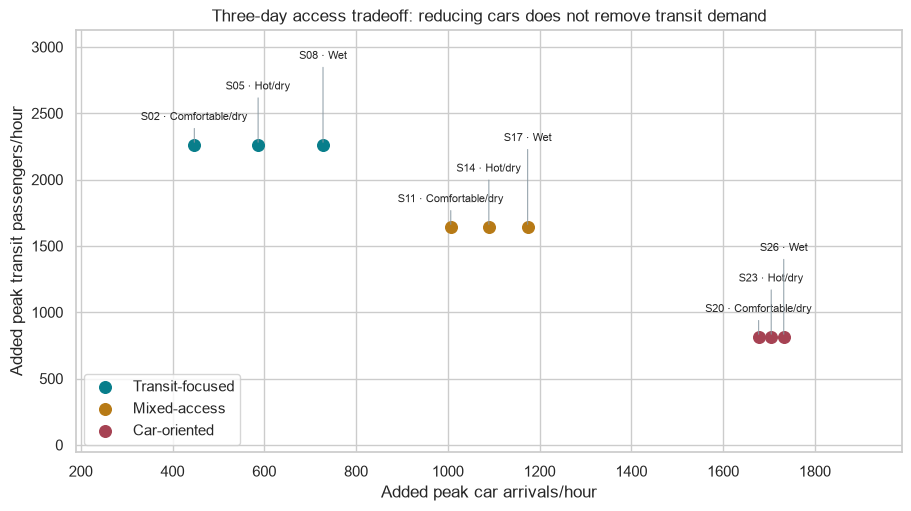

# Spark City convention: decision brief

Decision today: choose what to verify, not an unsupported winning venue/date.
Established: approximately 15,000 attendees and a Science, Technology, Engineering, Arts and Mathematics theme. Other numerical inputs are illustrative.
27 baseline cases = 3 access patterns × 3 weather conditions × 3 durations.

## Capacity before preference
For a transit-focused event, the modeled all-weather envelope calls for 7,444 residual rooms/night, 1,350 car arrivals/hour, 3,999 transit passengers/hour and 433 MWh/day. These are requirements to verify, not available capacity.

## Less car traffic shifts the service burden
In the three-day comfortable/dry comparison, transit-focused access reduces private-car travel by 93% relative to car-oriented access, while adding a paired median 1,439 transit passengers/hour and 110,089 planning dollars of organizer cost. This is built into the access assumptions.

## Manage arrivals, not just attendance
A 50% wider arriva

In [8]:
from html import escape

print("Building decision brief and checking scenario comparisons...", flush=True)
decision = OUTPUT / "decision_support"
decision.mkdir()
RESOURCE_METRICS = ["rooms_per_night", "peak_arriving_vehicles_per_hour",
                    "peak_transit_passengers_per_hour", "incremental_energy_kwh_per_day"]
RESOURCE_LABELS = ["Hotel rooms/night", "Car arrivals/hour", "Transit passengers/hour", "Electricity MWh/day"]
assumptions["decision_support"] = {
    "resource_quantile": .975, "joint_empirical_target": .90,
    "weather_envelope": "per-draw maximum across the three authored weather cases",
    "interventions": {"arrival_window_multiplier": 1.5, "people_per_car_addition": .5,
                      "venue_electricity_multiplier": .8},
    "intervention_costs": "not modeled", "adoption": "assumed achieved, not estimated",
}
groups = {key: part.set_index("draw").sort_index()
          for key, part in samples.groupby(["venue", "weather", "duration_days"])}
def capacity_envelope(frame):
    # 'higher' picks an observed quantile; round targets upward to avoid understating demand.
    limits = frame[RESOURCE_METRICS].quantile(.975, interpolation="higher")
    increments = pd.Series([1., 1., 1., 1000.], index=RESOURCE_METRICS)
    limits = np.ceil(limits / increments) * increments
    covered = frame[RESOURCE_METRICS].le(limits).all(axis=1)
    assert float(covered.mean()) >= .90
    return limits, float(covered.mean())

envelope_rows = []
for venue, duration in product(VENUES, DURATIONS):
    weather_stack = pd.concat({w: groups[(venue, w, duration)][RESOURCE_METRICS] for w in WEATHER})
    worst = weather_stack.groupby(level=1).max()
    targets, joint = capacity_envelope(worst)
    envelope_rows.append({"venue": venue, "duration_days": duration,
                          **targets.to_dict(), "joint_empirical_coverage": joint,
                          "draws": len(worst), "status": "requirements_to_verify_not_available_capacity"})
envelopes = pd.DataFrame(envelope_rows)
envelopes.to_csv(decision / "weather_stress_capacity_envelopes.csv", index=False)
display_envelopes = envelopes.rename(columns=dict(zip(RESOURCE_METRICS, RESOURCE_LABELS))).copy()
display_envelopes["Electricity MWh/day"] /= 1000

# Day 4 informs limitations, not event effects. Only attach a completed run matching selected Day 3.
matching_day4 = []
for path in (ROOT / "data/processed/day4").glob("*/manifest.json"):
    m = json.loads(path.read_text())
    if m.get("status") == "complete" and DAY3 and m.get("day3_run") == DAY3.name:
        matching_day4.append(path)
evidence = {"day3": context_lineage, "day4_run": None,
            "model_use": "context only; no convention intervention labels or calibrated causal effects"}
if matching_day4:
    path = sorted(matching_day4)[-1]
    m = json.loads(path.read_text())
    if m["day3_manifest_sha256"] != context_lineage["day3_manifest_sha256"]:
        raise ValueError("Day 4 context refers to a modified Day 3 manifest")
    metrics = pd.read_csv(path.parent / "test_metrics.csv")
    evidence.update({"day4_run": path.parent.name,
                     "day4_manifest_sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
                     "selected_test_metrics": metrics[metrics["selected"]].to_dict("records")})
    metrics.to_csv(decision / "day4_metrics_context_only.csv", index=False)
if DAY3:
    evidence["spatial_status"] = context_manifest.get("spatial_status", [])
(decision / "evidence_boundary.json").write_text(json.dumps(evidence, indent=2))

INTERVENTIONS = {
    "Spread arrivals over 50% longer window": ("arrival_window_hours", "multiply", 1.5),
    "Increase car occupancy by 0.5 people": ("people_per_car", "add", .5),
    "Reduce venue electricity intensity by 20%": ("venue_kwh_per_attendee_day", "multiply", .8),
}
intervention_rows = []
for case in catalog.to_dict("records"):
    key = (case["venue"], case["weather"], case["duration_days"])
    baseline = groups[key]
    for name, (parameter, operation, amount) in INTERVENTIONS.items():
        changed = draws.copy()
        changed[parameter] = changed[parameter] * amount if operation == "multiply" else changed[parameter] + amount
        alt = simulate(changed, ATTENDEES, case["duration_days"], VENUES[case["venue"]], WEATHER[case["weather"]]).set_index("draw").sort_index()
        row = {**case, "intervention": name}
        for metric in ["peak_arriving_vehicles_per_hour", "peak_transit_passengers_per_hour",
                       "private_vehicle_km", "incremental_energy_kwh"]:
            delta = alt[metric] - baseline[metric]
            percent = 100 * delta / baseline[metric].replace(0, np.nan)
            for q, label in [(.1, "p10"), (.5, "median"), (.9, "p90")]:
                row[metric + "_delta_" + label] = float(delta.quantile(q))
                row[metric + "_pct_" + label] = float(percent.quantile(q))
        # Demand-management changes do not create extra visitors or assumed organizer savings.
        for metric in ["rooms_per_night", "potential_gross_visitor_receipts", "organizer_cost"]:
            assert np.allclose(alt[metric], baseline[metric])
        if parameter == "arrival_window_hours":
            assert np.allclose(alt["peak_arriving_vehicles_per_hour"], baseline["peak_arriving_vehicles_per_hour"] / 1.5)
            assert np.allclose(alt["private_vehicle_km"], baseline["private_vehicle_km"])
            assert np.allclose(alt["incremental_energy_kwh"], baseline["incremental_energy_kwh"])
        if parameter == "people_per_car":
            assert (alt["private_vehicle_km"] <= baseline["private_vehicle_km"]).all()
            assert np.allclose(alt["peak_transit_passengers_per_hour"], baseline["peak_transit_passengers_per_hour"])
        if parameter == "venue_kwh_per_attendee_day":
            assert (alt["incremental_energy_kwh"] < baseline["incremental_energy_kwh"]).all()
            assert np.allclose(alt["private_vehicle_km"], baseline["private_vehicle_km"])
        intervention_rows.append(row)
interventions = pd.DataFrame(intervention_rows)
assert len(interventions) == 81 and interventions.groupby("scenario_id").size().eq(3).all()
interventions.to_csv(decision / "interventions_all_27_cases.csv", index=False)

# Paired marginal effects: quantify another event day, not subtraction of different stakeholders' budgets.
marginal_rows = []
for venue, weather in product(VENUES, WEATHER):
    for old_days, new_days in [(2, 3), (3, 4)]:
        before_day, after_day = groups[(venue, weather, old_days)], groups[(venue, weather, new_days)]
        row = {"venue": venue, "weather": weather, "from_days": old_days, "to_days": new_days}
        for metric in ["organizer_cost", "potential_gross_visitor_receipts", "room_nights",
                       "incremental_energy_kwh", "private_vehicle_km"]:
            delta = after_day[metric] - before_day[metric]
            for q, label in [(.1, "p10"), (.5, "median"), (.9, "p90")]:
                row[metric + "_" + label] = float(delta.quantile(q))
        assert np.allclose(after_day["rooms_per_night"], before_day["rooms_per_night"])
        assert np.allclose(after_day["peak_arriving_vehicles_per_hour"], before_day["peak_arriving_vehicles_per_hour"])
        marginal_rows.append(row)
marginals = pd.DataFrame(marginal_rows)
assert len(marginals) == 18
marginals.to_csv(decision / "one_extra_day_tradeoffs.csv", index=False)

# Compare access patterns at fixed weather/duration. No cross-weather winner or weighted score.
access_rows = []
for weather, duration in product(WEATHER, DURATIONS):
    car = groups[("Car-oriented", weather, duration)]
    for venue in ("Transit-focused", "Mixed-access"):
        candidate = groups[(venue, weather, duration)]
        row = {"venue": venue, "weather": weather, "duration_days": duration, "reference": "Car-oriented"}
        for metric in ["private_vehicle_km", "peak_arriving_vehicles_per_hour",
                       "peak_transit_passengers_per_hour", "organizer_cost"]:
            delta = candidate[metric] - car[metric]
            row[metric + "_median_delta"] = float(delta.median())
            row[metric + "_median_pct_change"] = float((100 * delta / car[metric]).median())
        access_rows.append(row)
access = pd.DataFrame(access_rows)
access.to_csv(decision / "access_tradeoffs.csv", index=False)

# A blank request form for REAL candidates: no invented venue/date/capacity entries.
request_rows = [
    ("Venue team", "Candidate venue and dates", "name/date", "Establish actual options and competing events"),
    ("Venue team", "Safe permitted attendee capacity and accessible egress", "people", "15,000 is attendance, not approved venue occupancy"),
    ("Hotel partners", "Residual rooms by night within agreed catchment", "rooms/night", "Separate ordinary bookings from event headroom"),
    ("Transport team", "Residual route-specific road arrivals", "vehicles/hour", "Citywide totals do not resolve local bottlenecks"),
    ("Transit operator", "Residual accessible transit capacity and service hours", "passengers/hour", "Low-car scenarios require transit service"),
    ("Utilities/venue", "Residual daily electricity and separate peak electric capacity", "kWh/day and kW", "Daily energy is not peak power"),
    ("Registration team", "Overnight share, room/car sharing, attendance by day", "survey", "Replace influential behavioral assumptions"),
    ("Event team", "Arrival window and timed-entry adoption", "hours/share", "Test whether staggered arrivals are achievable"),
    ("Finance team", "Venue, operations and intervention cost quotes", "common currency", "Keep organizer budget separate from visitor receipts"),
    ("Weather/environment team", "Date-specific weather evidence and fleet/dispersion inputs", "documented units", "No current air-concentration or date forecast"),
]
pd.DataFrame(request_rows, columns=["suggested_role", "information_requested", "unit", "why_it_matters"]).assign(
    candidate="", verified_value="", source="", verified_on="").to_csv(decision / "venue_evidence_request.csv", index=False)

# Reuse the existing reference scenario only as a worked example, not a preferred site/date.
ref_id = catalog.query("venue == 'Transit-focused' and weather == 'Comfortable/dry' and duration_days == 3").iloc[0]["scenario_id"]
ref_envelope = envelopes.query("venue == 'Transit-focused' and duration_days == 3").iloc[0]
ref_trade = access.query("venue == 'Transit-focused' and weather == 'Comfortable/dry' and duration_days == 3").iloc[0]
extra_day = marginals.query("venue == 'Transit-focused' and weather == 'Comfortable/dry' and from_days == 3").iloc[0]
pilot = interventions[interventions["scenario_id"].eq(ref_id)]
stagger = pilot[pilot["intervention"].eq("Spread arrivals over 50% longer window")].iloc[0]
pool = pilot[pilot["intervention"].eq("Increase car occupancy by 0.5 people")].iloc[0]
efficient = pilot[pilot["intervention"].eq("Reduce venue electricity intensity by 20%")].iloc[0]
brief_points = [
    ("Capacity before preference",
     f'For a transit-focused event, the modeled all-weather envelope calls for {ref_envelope["rooms_per_night"]:,.0f} residual rooms/night, '
     f'{ref_envelope["peak_arriving_vehicles_per_hour"]:,.0f} car arrivals/hour, '
     f'{ref_envelope["peak_transit_passengers_per_hour"]:,.0f} transit passengers/hour and '
     f'{ref_envelope["incremental_energy_kwh_per_day"]/1000:,.0f} MWh/day. These are requirements to verify, not available capacity.'),
    ("Less car traffic shifts the service burden",
     f'In the three-day comfortable/dry comparison, transit-focused access reduces private-car travel by '
     f'{-ref_trade["private_vehicle_km_median_pct_change"]:.0f}% relative to car-oriented access, while adding a paired median '
     f'{ref_trade["peak_transit_passengers_per_hour_median_delta"]:,.0f} transit passengers/hour and '
     f'{ref_trade["organizer_cost_median_delta"]:,.0f} planning dollars of organizer cost. This is built into the access assumptions.'),
    ("Manage arrivals, not just attendance",
     f'A 50% wider arrival window cuts modeled peak car and transit arrivals by '
     f'{-stagger["peak_arriving_vehicles_per_hour_pct_median"]:.1f}% without reducing total travel. '
     f'Adding 0.5 people/car reduces private-car distance by a paired median '
     f'{-pool["private_vehicle_km_pct_median"]:.1f}% in the worked example. Adoption and implementation costs need evidence.'),
    ("Venue efficiency is only part of electricity demand",
     f'A 20% reduction in venue electricity intensity reduces combined venue-plus-hotel electricity by only '
     f'{-efficient["incremental_energy_kwh_pct_median"]:.1f}% in the worked example; hotel electricity remains.'),
    ("An extra day is not free economic benefit",
     f'Extending the worked example from three to four days adds a paired median '
     f'{extra_day["room_nights_median"]:,.0f} room-nights and {extra_day["incremental_energy_kwh_median"]/1000:,.0f} MWh. '
     f'Potential visitor receipts increase by {extra_day["potential_gross_visitor_receipts_median"]/1e6:.2f} million planning dollars; '
     f'separate organizer costs increase by {extra_day["organizer_cost_median"]/1e6:.2f} million. These cannot be netted into city profit.'),
]
brief_lines = ["# Spark City convention: decision brief", "",
               "Decision today: choose what to verify, not an unsupported winning venue/date.",
               "Established: approximately 15,000 attendees and a Science, Technology, Engineering, Arts and Mathematics theme. Other numerical inputs are illustrative.",
               "27 baseline cases = 3 access patterns × 3 weather conditions × 3 durations.", ""]
for title, body in brief_points:
    brief_lines += ["## " + title, body, ""]
brief_lines += [
    "## Evidence boundary",
    "The weather envelope meets at least 90% of the simulated joint draws, not 90% real-world reliability.",
    "No actual venue capacity, date, cost quote or visitor behavior has been confirmed.",
    "Changing sensor coordinates prevent fixed-site interpretation. Day 4 has weak predictive performance",
    "and no convention intervention labels; its forecasts are not used to calibrate event effects.",
    "Weather is an input. Ambient air-quality changes, public safety and city profit are not estimated.",
    "## Team action",
    "Use decision_support/venue_evidence_request.csv to collect sourced values for actual venue/date candidates.",
    "Compare equally long events and all weather stresses before proposing a conditional shortlist.",
    "Retain the all-27 dashboard as the supporting appendix.",
    "## Sources for planning scope (not assumed numbers)",
    "- FHWA: https://ops.fhwa.dot.gov/publications/fhwaop04010/chapter3_05.htm",
    "- EPA: https://www.epa.gov/p2/green-meetings",
]
(OUTPUT / "decision_brief.md").write_text("\n".join(brief_lines) + "\n")

# Compact visual: show the hidden transit tradeoff rather than a misleading single winner.
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
for venue, color in zip(VENUES, ["#087e8b", "#b77a16", "#a64253"]):
    subset = summary[(summary["quantile"] == .5) & (summary["duration_days"] == 3) & summary["venue"].eq(venue)]
    ax.scatter(subset["peak_arriving_vehicles_per_hour"], subset["peak_transit_passengers_per_hour"], label=venue, color=color, s=70)
    for row in subset.itertuples():
        ax.annotate(f"{row.scenario_id} · {row.weather}", (row.peak_arriving_vehicles_per_hour, row.peak_transit_passengers_per_hour),
                    xytext=(0, 18 + 22 * list(WEATHER).index(row.weather)), textcoords="offset points",
                    ha="center", fontsize=8, arrowprops={"arrowstyle": "-", "color": "#8999a3", "lw": .7})
ax.set(xlabel="Added peak car arrivals/hour", ylabel="Added peak transit passengers/hour",
       title="Three-day access tradeoff: reducing cars does not remove transit demand")
ax.legend(loc="lower left")
ax.margins(x=.2, y=.6)
trade_chart = OUTPUT / "access_tradeoff.png"
fig.savefig(trade_chart, dpi=130)
plt.show(); plt.close(fig)

style = """body{font:17px system-ui;color:#193047;max-width:1050px;margin:32px auto;padding:0 20px;line-height:1.5}
h1{font-size:32px}h2{font-size:22px}.banner{padding:18px;background:#e8f3f4;border-left:5px solid #087e8b}
.card{padding:15px 20px;margin:16px 0;border:1px solid #ccd8df;border-radius:8px}
table{border-collapse:collapse;font-size:14px}td,th{border:1px solid #cbd5df;padding:10px}
img{max-width:100%}.scroll{overflow:auto}small{color:#43576a}@media print{body{font-size:12px;margin:0}.card{break-inside:avoid}a{color:inherit}}"""
parts = ['<!doctype html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">',
         '<title>Spark City convention — decision brief</title><style>'+style+'</style></head><body>',
         '<h1>15,000 people. What must the city be ready for?</h1>',
         '<p class="banner"><b>Decision today: agree on evidence and capacity requirements.</b><br>'
         '27 illustrative scenarios, not a confirmed venue/date recommendation. Only attendance is established numerically.</p>',
         '<p><a href="scenario_explorer.html">Explore all 27 scenarios</a> · '
         '<a href="decision_support/venue_evidence_request.csv">Download the venue evidence request</a></p>']
for title, body in brief_points:
    parts += ['<section class="card"><h2>'+escape(title)+'</h2><p>'+escape(body)+'</p></section>']
parts += ['<img alt="Three-day car-versus-transit demand tradeoff" src="data:image/png;base64,'+
          base64.b64encode(trade_chart.read_bytes()).decode()+'">',
          '<h2>Capacity questions for a three-day event</h2><p>All-weather stress-envelope targets. '
          'At least 90% joint empirical coverage of the chosen draws, not a real-world reliability guarantee. '
          'Daily requirements repeat across duration; reserve them for every day/night.</p><div class="scroll">',
          display_envelopes[display_envelopes.duration_days.eq(3)][["venue"]+RESOURCE_LABELS].to_html(index=False, float_format=lambda x:f"{x:,.0f}"),
          '</div><p>No actual headroom is confirmed. Venue occupancy, peak kW, egress and route-specific limits require separate checks.</p>',
          '<h2>Evidence boundary</h2><p>Day 4 is context only: weak predictive performance and no event-effect evidence. '
          'Source sensor locations change. Weather is a condition; ambient pollution and city profit are not predicted.</p>',
          '<h2>Three questions for the team</h2><ol><li>Which actual venue/date candidates can supply these resources?</li>'
          '<li>Can transport operators deliver the required accessible service and arrival schedule?</li>'
          '<li>Which survey results and quotes will replace the highest-impact assumptions?</li></ol>',
          '<p>Methodological scope: <a href="https://ops.fhwa.dot.gov/publications/fhwaop04010/chapter3_05.htm">FHWA event operations planning</a>; '
          '<a href="https://www.epa.gov/p2/green-meetings">EPA green meetings</a>. Neither validates the numerical assumptions.</p>',
          '<small>Local run '+escape(RUN_ID)+'; see decision_support/evidence_boundary.json for source lineage.</small></body></html>']
(OUTPUT / "decision_brief.html").write_text("\n".join(parts))
dashboard_path = OUTPUT / "dashboard.html"
dashboard = dashboard_path.read_text()
dashboard = dashboard.replace("<body>", '<body><p class="notice"><b>Start here:</b> '
                              '<a href="decision_brief.html">Read the convention decision brief</a> — capacity targets, '
                              'transport tradeoffs and intervention experiments.</p>', 1)
dashboard_path.write_text(dashboard)

# Verify exports and coverage before the final notebook cell can mark the run complete.
assert len(envelopes) == 9
assert (envelopes.joint_empirical_coverage >= .9).all()
assert len(pd.read_csv(decision / "interventions_all_27_cases.csv")) == 81
assert len(pd.read_csv(decision / "one_extra_day_tradeoffs.csv")) == 18
assert len(readable) == 27
assert (OUTPUT / "decision_brief.html").exists()
print("\n".join(brief_lines))
print("Team presentation:", OUTPUT / "decision_brief.html")

# The primary deliverable is the city-planner dashboard; detailed tables remain an appendix.
(OUTPUT / "scenario_explorer.html").write_text((OUTPUT / "dashboard.html").read_text())
planner_data = []
for case in catalog.to_dict("records"):
    stats = summary[summary.scenario_id.eq(case["scenario_id"])].set_index("quantile")
    envelope = envelopes[(envelopes.venue == case["venue"]) & (envelopes.duration_days == case["duration_days"])].iloc[0]
    metrics = {metric: {"median": float(stats.loc[.5, metric]), "p10": float(stats.loc[.1, metric]),
                        "p90": float(stats.loc[.9, metric])} for metric in METRICS}
    actions = []
    for row in interventions[interventions.scenario_id.eq(case["scenario_id"])].to_dict("records"):
        actions.append({"name": row["intervention"],
                        "cars_pct": row["peak_arriving_vehicles_per_hour_pct_median"],
                        "transit_pct": row["peak_transit_passengers_per_hour_pct_median"],
                        "travel_pct": row["private_vehicle_km_pct_median"],
                        "energy_pct": row["incremental_energy_kwh_pct_median"]})
    planner_data.append({**case, "metrics": metrics, "targets": {k: float(envelope[k]) for k in RESOURCE_METRICS},
                         "joint_coverage": float(envelope["joint_empirical_coverage"]), "actions": actions})
planner_payload = json.dumps(planner_data, allow_nan=False).replace("<", "\\u003c")
steam_questions = [
    "Confirm event attendance by day and whether 15,000 means unique attendees or total admissions.",
    "Science/technology demonstrations: confirm equipment power, ventilation and any specialist safety requirements.",
    "Engineering exhibits: confirm loading access, floor loads, setup/teardown times and delivery schedules.",
    "Arts programming: confirm performance schedules, sound requirements and audience movement between spaces.",
    "Math sessions and workshops: confirm room layouts, accessibility, capacity and concurrent session schedules.",
    "For all disciplines: identify internet requirements, staffing, waste, catering and contingency plans.",
]
pd.DataFrame({"planning_question": steam_questions, "confirmed_answer": "", "source": ""}).to_csv(
    decision / "steam_program_requirements.csv", index=False)
planner_style = """
:root{--ink:#193047;--accent:#087e8b;--muted:#4d6373;--line:#d5e0e7}
body{margin:0;background:#f3f7f9;color:var(--ink);font:16px system-ui;line-height:1.5}
header{background:#16374a;color:white;padding:28px max(24px,calc((100vw - 1200px)/2))}
header h1{margin:0;font-size:30px}header p{margin:8px 0}
main{max-width:1200px;margin:auto;padding:24px}
section{background:white;border:1px solid var(--line);border-radius:10px;padding:22px;margin-bottom:20px}
h2{font-size:22px;margin-top:0}h3{font-size:17px}
.controls,.cards,.capacities{display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:16px}
label{display:block;font-weight:600}select,input{display:block;box-sizing:border-box;width:100%;padding:10px;margin-top:6px;font:inherit;border:1px solid #a7bbc8;border-radius:5px}
.card{background:#f1f7f8;border-left:4px solid var(--accent);padding:14px}.value{font-size:26px;font-weight:700}
small,.muted{color:var(--muted)}.notice{background:#fff3ce;padding:14px;border-radius:6px}
.scroll{overflow-x:auto}table{border-collapse:collapse;width:100%;font-size:14px}td,th{text-align:left;border-bottom:1px solid var(--line);padding:12px}
button{background:var(--accent);color:white;border:0;border-radius:5px;padding:12px;font:inherit;cursor:pointer}
a{color:#076678}#capacity-summary{font-weight:600}.capacities{grid-template-columns:repeat(4,minmax(0,1fr))}
@media(max-width:760px){.controls,.cards,.capacities{grid-template-columns:1fr}header h1{font-size:24px}}
@media print{body{background:white;font-size:12px}header{color:#193047;background:white;padding:15px}section{break-inside:avoid}button{display:none}main{padding:0}}
"""
planner_html = """<!doctype html><html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Spark City S.T.E.A.M. convention planner</title><style>""" + planner_style + """</style></head>
<body><header><h1>Spark City S.T.E.A.M. Convention Planner</h1>
<p>Science · Technology · Engineering · Arts · Mathematics</p>
<p>15,000 expected attendees · 27 planning scenarios · Resource requirements before venue selection</p></header>
<main><section><h2>1. Choose the scenario to examine</h2>
<p class="notice"><b>Planning model, not a verified city forecast.</b> Attendance and the S.T.E.A.M. theme are established.
All other numerical inputs are illustrative. Access types are not actual venues; weather is not a date prediction.</p>
<div class="controls">
<label>Venue access pattern<select id="venue"><option>Transit-focused</option><option>Mixed-access</option><option>Car-oriented</option></select></label>
<label>Weather stress condition<select id="weather"><option>Comfortable/dry</option><option>Hot/dry</option><option>Wet</option></select></label>
<label>Event duration<select id="duration"><option value="2">2 days</option><option value="3" selected>3 days</option><option value="4">4 days</option></select></label>
</div><p id="scenario-title"></p>
<p class="muted">Assumes 15,000 unique people attend every day. Hotel nights equal event days. No actual date or location selected.</p>
</section><section><h2>2. Understand added event demand</h2>
<p>Large values are medians; ranges are P10–P90 of the chosen assumptions—not confidence intervals.
These are added event requirements, not total city demand.</p><div id="metrics" class="cards"></div>
<p><b>Air quality:</b> ambient concentrations are not estimated. Private-car travel is an activity measure, not total emissions.
<b>Weather:</b> an input condition, not an event-caused change.</p>
<p>Visitor receipts and organizer expenses belong to different stakeholders. Do not subtract them to claim city profit.</p>
</section><section><h2>3. Compare known capacity with the weather-stress envelope</h2>
<p>Targets cover all three modeled weather conditions for the selected access pattern and duration.
Each resource uses the 97.5th percentile of its per-draw weather maximum, rounded up;
joint coverage is checked directly. This is not a real-world reliability guarantee.</p>
<p id="coverage"></p><p>Enter <b>residual capacity after normal city demand</b>. Leave unknown values blank.
Values stay in this page only and reset on reload. Energy input is daily kWh, not peak kW.</p>
<div class="capacities">
<label>Rooms available/night<input id="cap-rooms" type="number" min="0" step="1" placeholder="Unknown"></label>
<label>Car arrivals/hour<input id="cap-cars" type="number" min="0" step="any" placeholder="Unknown"></label>
<label>Transit passengers/hour<input id="cap-transit" type="number" min="0" step="any" placeholder="Unknown"></label>
<label>Electricity kWh/day<input id="cap-energy" type="number" min="0" step="any" placeholder="Unknown"></label>
</div><div class="scroll"><table><thead><tr><th>Resource</th><th>Stress target</th><th>Entered capacity</th><th>Preliminary gap check</th></tr></thead><tbody id="capacity-rows"></tbody></table></div>
<p id="capacity-summary" aria-live="polite"></p>
<p class="notice">Meeting these four targets is <b>not venue approval</b>. Confirm permitted occupancy, route bottlenecks,
peak electricity load, accessibility, emergency egress and service availability for every event day/night.
A deficit means the entered capacity is below this stress target—not proof every simulated case is infeasible.</p>
</section><section><h2>4. Test operational options</h2>
<p>Changes below are paired median percentages versus the selected baseline. Each intervention is tested alone.
Negative values mean lower modeled demand. Costs, adoption and real-world effectiveness are unverified.</p>
<div class="scroll"><table><thead><tr><th>Illustrative intervention</th><th>Peak cars</th><th>Peak transit</th><th>Private-car distance</th><th>Total electricity</th></tr></thead><tbody id="actions"></tbody></table></div>
<p>Staggering arrivals changes peak load, not total journeys. Higher car occupancy changes vehicle demand, not attendee count.
Venue efficiency does not remove hotel electricity demand. S.T.E.A.M. equipment loads require separate quotes/specifications.</p>
</section><section><h2>5. Resolve the S.T.E.A.M. program requirements</h2><ul>""" + "".join("<li>"+escape(q)+"</li>" for q in steam_questions) + """</ul>
<p>These are questions to investigate, not confirmed activities or additional modeled loads.</p>
<p><a href="decision_support/steam_program_requirements.csv">Program requirements worksheet</a> ·
<a href="decision_support/venue_evidence_request.csv">Venue evidence request</a></p>
</section><section><h2>6. Discuss the decision with the team</h2>
<p><b>No automatic winner:</b> fewer cars can mean more transit demand. Longer events increase resource requirements
and potential receipts together. Choose a venue/date only after replacing assumptions with sourced local evidence.</p>
<p><a href="decision_brief.html">Read the five planning insights</a> · <a href="scenario_explorer.html">All 27 cases and charts</a> ·
<a href="decision_support/one_extra_day_tradeoffs.csv">Cost/resource effect of one extra day</a></p>
<button id="download">Download selected scenario and entered capacity</button>
<p class="muted">Day 4 forecasts are not convention-impact estimates. Changing sensor coordinates prevent fixed-site interpretations.
No database changes, notifications or automated approvals.</p>
<p>Planning scope: <a href="https://ops.fhwa.dot.gov/publications/fhwaop04010/chapter3_05.htm">FHWA event operations planning</a>;
<a href="https://www.epa.gov/p2/green-meetings">EPA green meetings</a>. Sources do not validate assumed numbers.</p>
<small>Run: """ + escape(RUN_ID) + """</small></section></main>
<script id="scenario-data" type="application/json">""" + planner_payload + """</script>
<script>
const cases = JSON.parse(document.getElementById("scenario-data").textContent);
const el = id => document.getElementById(id);
const specs = [
 ["peak_arriving_vehicles_per_hour","Peak car arrivals","cars/hour",1,0],
 ["peak_transit_passengers_per_hour","Peak transit arrivals","people/hour",1,0],
 ["rooms_per_night","Hotel rooms required","rooms/night",1,0],
 ["incremental_energy_kwh","Total added electricity","MWh",1000,1],
 ["potential_gross_visitor_receipts","Potential visitor receipts","million planning $",1e6,2],
 ["organizer_cost","Separate organizer expenses","million planning $",1e6,2]
];
const resources = [
 ["rooms_per_night","Hotel rooms/night","cap-rooms"],
 ["peak_arriving_vehicles_per_hour","Car arrivals/hour","cap-cars"],
 ["peak_transit_passengers_per_hour","Transit passengers/hour","cap-transit"],
 ["incremental_energy_kwh_per_day","Electricity kWh/day","cap-energy"]
];
const fmt=(x,d=0)=>Number(x).toLocaleString("en-US",{minimumFractionDigits:d,maximumFractionDigits:d});
function selectedCase(){
 return cases.find(c=>c.venue===el("venue").value && c.weather===el("weather").value && c.duration_days===Number(el("duration").value));
}
function capacityResult(c){
 return resources.map(([key,label,id])=>{
  const raw=el(id).value.trim(), value=raw===""?null:Number(raw), target=c.targets[key];
  const invalid=value!==null && (!Number.isFinite(value)||value<0);
  const status=invalid?"Enter a nonnegative number":value===null?"Unknown — not assessed":
    value<target?"Below target by "+fmt(target-value):"Meets this modeled target";
  return {resource:label,target,entered_capacity:invalid?null:value,status};
 });
}
function render(){
 const c=selectedCase();
 el("scenario-title").textContent=c.scenario_id+" · "+c.venue+" · "+c.weather+" · "+c.duration_days+" days";
 el("metrics").innerHTML=specs.map(([key,label,unit,scale,d])=>{
  const m=c.metrics[key];
  return '<div class="card"><h3>'+label+'</h3><div class="value">'+fmt(m.median/scale,d)+'</div><div>'+unit+
   '</div><small>Assumption range: '+fmt(m.p10/scale,d)+'–'+fmt(m.p90/scale,d)+'</small></div>';
 }).join("");
 el("coverage").textContent="Computed joint coverage: "+fmt(100*c.joint_coverage,1)+"% of authored draws. Targets are requirements to verify, not available capacity.";
 const checks=capacityResult(c);
 el("capacity-rows").innerHTML=checks.map(r=>'<tr><td>'+r.resource+'</td><td>'+fmt(r.target)+'</td><td>'+
   (r.entered_capacity===null?"Unknown":fmt(r.entered_capacity))+'</td><td>'+r.status+'</td></tr>').join("");
 const missing=checks.some(r=>r.entered_capacity===null), deficits=checks.filter(r=>r.entered_capacity!==null && r.entered_capacity<r.target).length;
 el("capacity-summary").textContent=(missing?"Incomplete: some capacities are unknown or invalid. ":"")+
   (deficits?deficits+" resource(s) below the modeled stress target.":missing?"":"All four entered capacities meet these modeled targets; full feasibility is still unassessed.");
 el("actions").innerHTML=c.actions.map(a=>'<tr><td>'+a.name+'</td>'+
   ["cars_pct","transit_pct","travel_pct","energy_pct"].map(k=>'<td>'+fmt(a[k],1)+'%</td>').join("")+'</tr>').join("");
}
["venue","weather","duration"].forEach(id=>el(id).addEventListener("change",render));
resources.forEach(r=>el(r[2]).addEventListener("input",render));
el("download").addEventListener("click",()=>{
 const c=selectedCase(), report={scenario:c,capacity_inputs:capacityResult(c),
  caution:"Illustrative planning assumptions. User-entered capacities are unverified. Not venue approval."};
 const a=document.createElement("a"), url=URL.createObjectURL(new Blob([JSON.stringify(report,null,2)],{type:"application/json"}));
 a.href=url;a.download="steam-planning-"+c.scenario_id+".json";a.click();URL.revokeObjectURL(url);
});
render();
</script></body></html>"""
(OUTPUT / "dashboard.html").write_text(planner_html)
assumptions["event_theme"] = "Science, Technology, Engineering, Arts and Mathematics"
assert len(planner_data) == 27
print("Primary city-planner dashboard:", OUTPUT / "dashboard.html")


## 9. Reproducibility and next iteration
Retain the manifest, assumptions and samples together. Compare assumption revisions, not just output medians. One-at-a-time or correlated-input experiments may change results: current independent triangular inputs are a simplification. Shared draws make scenario differences reproducible but do not make the assumed distributions true.

The accompanying `docs/convention_model_decisions.md` records the rationale and evidence gaps. This notebook is ready to accept real venue/date inputs once the team obtains them; it is not an automatic site-selection decision.

In [9]:
(OUTPUT / "assumptions.json").write_text(json.dumps(assumptions, indent=2))
manifest = {"status": "complete", "run_id": RUN_ID, "attendees": ATTENDEES,
            "event_theme": assumptions["event_theme"],
            "decision_support": {"intervention_comparisons": len(interventions), "capacity_envelopes": len(envelopes),
                                 "day4_context_run": evidence["day4_run"], "primary_dashboard": "dashboard.html"},
            "scenario_count": len(results), "draws_per_scenario": DRAWS, "seed": SEED,
            "day3_context_run": DAY3.name if DAY3 else None,
            "context_lineage": context_lineage,
            "scenario_design": "3 access patterns x 3 weather conditions x 3 durations",
            "assumptions_sha256": hashlib.sha256((OUTPUT / "assumptions.json").read_bytes()).hexdigest(),
            "notebook_sha256": hashlib.sha256((ROOT / "notebooks/Hakeem_convention_scenarios.ipynb").read_bytes()).hexdigest(),
            "pandas": pd.__version__, "numpy": np.__version__,
            "interval_interpretation": "conditional Monte Carlo assumption quantiles, not confidence intervals",
            "air_quality": "private-car activity; optional emissions factors; no ambient concentration estimate",
            "weather": "external condition; no convention-induced weather model",
            "financial_scope": "potential direct visitor receipts and separate organizer costs; no city-profit claim",
            "selection_status": "actual venue/date undetermined"}
assert len(samples) == len(VENUES) * len(WEATHER) * len(DURATIONS) * DRAWS
assert pd.read_parquet(OUTPUT / "simulation_draws.parquet").shape == samples.shape
assert len(pd.read_csv(OUTPUT / "scenario_comparison_readable.csv")) == 27
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
print("Verified complete manifest saved.")
print("Completed:", OUTPUT)
print("City-planner dashboard:", OUTPUT / "dashboard.html")


Verified complete manifest saved.
Completed: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/convention/20260914T212915633517Z
City-planner dashboard: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/convention/20260914T212915633517Z/dashboard.html
